<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/011_agent_tool_use.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Quando um LLM deve usar ferramentas e como avaliar sua trajetória?

**Área:** Agentic AI  
**Tipo de problema:** Tool use, execução multi-step e avaliação de agentes

### Pergunta de estudo

> Dar ferramentas a um LLM melhora sua capacidade de resolver tarefas que dependem de dados privados, cálculos e operações externas? E como avaliar não apenas a resposta final, mas também o caminho percorrido pelo agente?

Até o Study 010, o sistema utilizava recuperação para ampliar conhecimento.

Neste estudo, o modelo passa a decidir:

1. se precisa de uma ferramenta;
2. qual ferramenta utilizar;
3. quais argumentos fornecer;
4. se precisa usar outra ferramenta após observar o resultado;
5. quando possui informação suficiente para responder.

### Arquitetura

```text
                 ┌──────────────┐
                 │    Usuário   │
                 └──────┬───────┘
                        ↓
                 ┌──────────────┐
                 │     LLM      │
                 └──────┬───────┘
                        │
             ┌──────────┴──────────┐
             │                     │
      resposta final          tool call
                                   ↓
                           ┌──────────────┐
                           │   Executor   │
                           └──────┬───────┘
                                  ↓
                           ┌──────────────┐
                           │ Ferramenta   │
                           └──────┬───────┘
                                  ↓
                           tool response
                                  ↓
                                 LLM
```

### Capacidades estudadas

- tool selection;
- argument generation;
- multi-step execution;
- state/history;
- error handling;
- stopping condition;
- trajectory evaluation.

### Comparação

O mesmo modelo será executado em dois modos:

**Baseline**
```text
Pergunta → LLM → Resposta
```

**Agent**
```text
Pergunta → LLM → Tool → Resultado → LLM → ... → Resposta
```

### Princípio central

Um agente não deve ser avaliado somente por:

> “A resposta parece boa?”

Também devemos perguntar:

> “Ele utilizou as ferramentas corretas, com os argumentos corretos, na ordem necessária e sem passos desnecessários?”


## 1. Configuração do ambiente

O notebook utiliza a API de **tool use do Hugging Face Transformers**.

Ferramentas Python são convertidas em JSON Schema a partir de:

- nome da função;
- type hints;
- docstring em estilo Google.

O LLM não executa funções diretamente.  
Ele solicita uma chamada, e o nosso executor realiza a operação e devolve o resultado ao histórico.

> **GPU no Google Colab é recomendada.**

O modelo é carregado em 4-bit para reduzir consumo de memória.


In [1]:
!pip -q install -U transformers accelerate bitsandbytes pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 43.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [2]:
import ast
import json
import math
import operator
import random
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from transformers.utils import get_json_schema

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "NousResearch/Hermes-2-Pro-Llama-3-8B"

MAX_AGENT_STEPS = 8
MAX_NEW_TOKENS = 256

print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

if not torch.cuda.is_available():
    print(
        "ATENÇÃO: este notebook foi planejado para execução "
        "com GPU no Google Colab."
    )


PyTorch: 2.11.0+cu128
GPU disponível: True


## 2. Ambiente privado do agente

Para avaliar tool use objetivamente, criaremos um pequeno ambiente operacional fictício.

O catálogo **não é incluído no prompt do modelo**.

Portanto, o LLM só consegue responder corretamente sobre:

- preços;
- estoque;
- peso;
- warehouse;
- reorder point;

se utilizar a ferramenta de consulta.

Esse desenho cria uma distinção clara entre:

- conhecimento interno do modelo;
- conhecimento externo disponível por ferramentas.


In [3]:
PRODUCT_CATALOG = {
    "A100": {
        "name": "Precision Sensor",
        "unit_price": 18.75,
        "stock": 42,
        "weight_kg": 0.32,
        "warehouse": "North",
        "reorder_point": 15,
    },
    "B200": {
        "name": "Edge Camera",
        "unit_price": 64.90,
        "stock": 18,
        "weight_kg": 0.55,
        "warehouse": "East",
        "reorder_point": 20,
    },
    "C300": {
        "name": "Control Module",
        "unit_price": 39.50,
        "stock": 73,
        "weight_kg": 0.18,
        "warehouse": "North",
        "reorder_point": 25,
    },
    "D400": {
        "name": "Battery Pack",
        "unit_price": 27.30,
        "stock": 11,
        "weight_kg": 1.25,
        "warehouse": "South",
        "reorder_point": 12,
    },
    "E500": {
        "name": "Gateway",
        "unit_price": 89.00,
        "stock": 9,
        "weight_kg": 0.48,
        "warehouse": "East",
        "reorder_point": 10,
    },
}

SHIPPING_RATES = {
    "zone_1": 12.50,
    "zone_2": 18.00,
    "zone_3": 25.00,
}

catalog_df = (
    pd.DataFrame(PRODUCT_CATALOG)
    .T
    .rename_axis("sku")
)

display(catalog_df)

display(
    pd.Series(
        SHIPPING_RATES,
        name="price_per_kg",
    ).to_frame()
)


,name,unit_price,stock,weight_kg,warehouse,reorder_point
sku,,,,,,
A100,Precision Sensor,18.75,42,0.32,North,15
B200,Edge Camera,64.9,18,0.55,East,20
C300,Control Module,39.5,73,0.18,North,25
D400,Battery Pack,27.3,11,1.25,South,12
E500,Gateway,89.0,9,0.48,East,10


,price_per_kg
zone_1,12.5
zone_2,18.0
zone_3,25.0


## 3. Ferramenta 1 — consulta de produto

A ferramenta retorna dados privados do catálogo.

IDs inexistentes produzem uma resposta estruturada de erro em vez de uma exceção.


In [4]:
def lookup_product(sku: str) -> str:
    """
    Look up a product in the private catalog by SKU.

    Args:
        sku: Product identifier such as A100, B200, C300, D400, or E500.

    Returns:
        A JSON string with product information or a not_found error.
    """
    normalized_sku = str(sku).strip().upper()

    product = PRODUCT_CATALOG.get(
        normalized_sku
    )

    if product is None:
        return json.dumps({
            "status": "not_found",
            "sku": normalized_sku,
        })

    return json.dumps({
        "status": "ok",
        "sku": normalized_sku,
        **product,
    })


## 4. Ferramenta 2 — calculadora segura

Agentes não devem executar `eval()` diretamente sobre texto produzido pelo LLM.

A calculadora utiliza `ast` e permite apenas:

- números;
- soma;
- subtração;
- multiplicação;
- divisão;
- potência limitada;
- módulo;
- operadores unários.

Chamadas fora desse subconjunto são rejeitadas.


In [5]:
_ALLOWED_BINARY_OPERATORS = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Mod: operator.mod,
    ast.Pow: operator.pow,
}

_ALLOWED_UNARY_OPERATORS = {
    ast.UAdd: operator.pos,
    ast.USub: operator.neg,
}


def _safe_eval_node(node):
    if isinstance(node, ast.Expression):
        return _safe_eval_node(
            node.body
        )

    if (
        isinstance(node, ast.Constant)
        and isinstance(
            node.value,
            (int, float),
        )
    ):
        return node.value

    if isinstance(node, ast.BinOp):
        operator_type = type(node.op)

        if (
            operator_type
            not in _ALLOWED_BINARY_OPERATORS
        ):
            raise ValueError(
                "Unsupported operator."
            )

        left = _safe_eval_node(
            node.left
        )
        right = _safe_eval_node(
            node.right
        )

        if (
            operator_type is ast.Pow
            and abs(right) > 10
        ):
            raise ValueError(
                "Exponent is too large."
            )

        return (
            _ALLOWED_BINARY_OPERATORS[
                operator_type
            ](
                left,
                right,
            )
        )

    if isinstance(node, ast.UnaryOp):
        operator_type = type(node.op)

        if (
            operator_type
            not in _ALLOWED_UNARY_OPERATORS
        ):
            raise ValueError(
                "Unsupported unary operator."
            )

        return (
            _ALLOWED_UNARY_OPERATORS[
                operator_type
            ](
                _safe_eval_node(
                    node.operand
                )
            )
        )

    raise ValueError(
        "Expression contains unsupported syntax."
    )


def calculator(expression: str) -> float:
    """
    Evaluate a basic arithmetic expression safely.

    Args:
        expression: Arithmetic expression using numbers and basic operators.

    Returns:
        The numeric result.
    """
    tree = ast.parse(
        expression,
        mode="eval",
    )

    result = _safe_eval_node(
        tree
    )

    if not math.isfinite(
        float(result)
    ):
        raise ValueError(
            "Result is not finite."
        )

    return float(result)


## 5. Ferramenta 3 — conversão de unidades

A ferramenta suporta massa em:

- kg;
- g;
- lb.

A conversão usa kg como unidade intermediária.


In [6]:
_MASS_TO_KG = {
    "kg": 1.0,
    "g": 0.001,
    "lb": 0.45359237,
}


def convert_units(
    value: float,
    from_unit: str,
    to_unit: str,
) -> float:
    """
    Convert a mass value between kilograms, grams, and pounds.

    Args:
        value: Numeric mass value to convert.
        from_unit: Source unit. Supported values are kg, g, and lb.
        to_unit: Destination unit. Supported values are kg, g, and lb.

    Returns:
        The converted numeric value.
    """
    source = (
        str(from_unit)
        .strip()
        .lower()
    )

    destination = (
        str(to_unit)
        .strip()
        .lower()
    )

    if source not in _MASS_TO_KG:
        raise ValueError(
            f"Unsupported source unit: {source}"
        )

    if destination not in _MASS_TO_KG:
        raise ValueError(
            f"Unsupported destination unit: {destination}"
        )

    value_kg = (
        float(value)
        * _MASS_TO_KG[source]
    )

    converted = (
        value_kg
        / _MASS_TO_KG[destination]
    )

    return float(converted)


## 6. Ferramenta 4 — tarifa de envio

A tarifa é privada e expressa em preço por quilograma.


In [7]:
def get_shipping_rate(zone: str) -> float:
    """
    Get the private shipping price per kilogram for a delivery zone.

    Args:
        zone: Shipping zone identifier. Supported values are zone_1, zone_2, and zone_3.

    Returns:
        Shipping price per kilogram.
    """
    normalized_zone = (
        str(zone)
        .strip()
        .lower()
    )

    if normalized_zone not in SHIPPING_RATES:
        raise ValueError(
            f"Unknown shipping zone: {normalized_zone}"
        )

    return float(
        SHIPPING_RATES[
            normalized_zone
        ]
    )


## 7. Registro de ferramentas

As próprias funções Python são passadas ao tokenizer.

O Transformers converte as assinaturas em JSON Schema.


In [8]:
TOOLS = [
    lookup_product,
    calculator,
    convert_units,
    get_shipping_rate,
]

TOOL_REGISTRY = {
    tool.__name__: tool
    for tool in TOOLS
}

tool_schemas = [
    get_json_schema(tool)
    for tool in TOOLS
]

display(
    pd.DataFrame([
        {
            "tool": schema["function"]["name"],
            "description":
                schema["function"]["description"],
            "required":
                schema["function"]["parameters"]
                .get("required", []),
        }
        for schema in tool_schemas
    ])
)


,tool,description,required
0,lookup_product,Look up a product in the private catalog by SKU.,[sku]
1,calculator,Evaluate a basic arithmetic expression safely.,[expression]
2,convert_units,"Convert a mass value between kilograms, grams,...","[value, from_unit, to_unit]"
3,get_shipping_rate,Get the private shipping price per kilogram fo...,[zone]


## 8. Executor seguro de ferramentas

O executor é uma camada de controle entre o modelo e o código.

Ele:

1. valida o nome da ferramenta;
2. garante que argumentos sejam um dicionário;
3. captura erros;
4. sempre devolve resultado serializável;
5. registra sucesso ou falha.

Essa separação é importante: **o LLM propõe uma ação; a aplicação decide se ela pode ser executada**.


In [9]:
def execute_tool_call(tool_call):
    tool_name = tool_call.get(
        "name"
    )

    arguments = tool_call.get(
        "arguments",
        {},
    )

    if tool_name not in TOOL_REGISTRY:
        return {
            "ok": False,
            "tool": tool_name,
            "error": "unknown_tool",
        }

    if not isinstance(
        arguments,
        dict,
    ):
        return {
            "ok": False,
            "tool": tool_name,
            "error": "arguments_must_be_object",
        }

    tool = TOOL_REGISTRY[
        tool_name
    ]

    try:
        value = tool(
            **arguments
        )

        return {
            "ok": True,
            "tool": tool_name,
            "arguments": arguments,
            "result": value,
        }

    except Exception as exc:
        return {
            "ok": False,
            "tool": tool_name,
            "arguments": arguments,
            "error": type(exc).__name__,
            "message": str(exc),
        }


## 9. Demonstração de validação de ferramentas

Uma chamada inválida não deve derrubar o agente.

O erro retorna ao modelo, que pode corrigir os argumentos em um passo posterior.


In [10]:
valid_demo = execute_tool_call({
    "name": "convert_units",
    "arguments": {
        "value": 2.5,
        "from_unit": "kg",
        "to_unit": "g",
    },
})

invalid_demo = execute_tool_call({
    "name": "convert_units",
    "arguments": {
        "value": 2.5,
        "from_unit": "stone",
        "to_unit": "kg",
    },
})

print("CHAMADA VÁLIDA")
print(
    json.dumps(
        valid_demo,
        indent=2,
    )
)

print("\nCHAMADA INVÁLIDA")
print(
    json.dumps(
        invalid_demo,
        indent=2,
    )
)


CHAMADA VÁLIDA
{
  "ok": true,
  "tool": "convert_units",
  "arguments": {
    "value": 2.5,
    "from_unit": "kg",
    "to_unit": "g"
  },
  "result": 2500.0
}

CHAMADA INVÁLIDA
{
  "ok": false,
  "tool": "convert_units",
  "arguments": {
    "value": 2.5,
    "from_unit": "stone",
    "to_unit": "kg"
  },
  "error": "ValueError",
  "message": "Unsupported source unit: stone"
}


## 10. Carregamento do modelo

O Hermes 2 Pro Llama 3 é utilizado por possuir suporte explícito a tool/function calling.

A quantização em 4-bit torna a execução mais viável em GPUs comuns do Colab.


In [11]:
quantization_config = (
    BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=(
            torch.float16
        ),
        bnb_4bit_use_double_quant=True,
    )
)

tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_NAME
    )
)

model = (
    AutoModelForCausalLM
    .from_pretrained(
        MODEL_NAME,
        quantization_config=(
            quantization_config
        ),
        device_map="auto",
    )
)

print(
    "Modelo carregado:",
    MODEL_NAME,
)

print(
    "Memória aproximada dos parâmetros (GB):",
    round(
        model.get_memory_footprint()
        / 1024**3,
        2,
    ),
)


config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/56.1k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Modelo carregado: NousResearch/Hermes-2-Pro-Llama-3-8B
Memória aproximada dos parâmetros (GB): 5.21


## 11. Geração com chat template

A função abaixo aceita opcionalmente ferramentas.

Quando `tools` é fornecido, o schema das funções é incorporado ao chat template.


In [12]:
def generate_model_response(
    messages,
    tools=None,
    max_new_tokens=MAX_NEW_TOKENS,
):
    template_kwargs = {
        "conversation": messages,
        "add_generation_prompt": True,
        "return_dict": True,
        "return_tensors": "pt",
    }

    if tools is not None:
        template_kwargs[
            "tools"
        ] = tools

    inputs = (
        tokenizer
        .apply_chat_template(
            **template_kwargs
        )
        .to(model.device)
    )

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=(
                tokenizer.eos_token_id
            ),
        )

    generated_tokens = outputs[
        :,
        inputs["input_ids"]
        .shape[1]:,
    ]

    raw_response = tokenizer.decode(
        generated_tokens[0],
        skip_special_tokens=False,
    )

    return raw_response.strip()


## 12. Parser de tool calls

O formato de saída pode incluir:

```text
<tool_call>
{"name": "...", "arguments": {...}}
</tool_call>
```

O parser separa tool calls de respostas finais.

Se JSON inválido for produzido, a ocorrência é registrada como erro de parsing.


In [13]:
def extract_tool_call(
    raw_response,
):
    match = re.search(
        r"<tool_call>\s*(\{.*?\})\s*</tool_call>",
        raw_response,
        flags=re.S,
    )

    if not match:
        return None, None

    payload_text = (
        match.group(1)
    )

    try:
        payload = json.loads(
            payload_text
        )

        return payload, None

    except json.JSONDecodeError as exc:
        return None, {
            "type": "invalid_tool_json",
            "message": str(exc),
            "raw": payload_text,
        }


def clean_final_response(
    raw_response,
):
    text = re.sub(
        r"<\|im_end\|>|<\|eot_id\|>|</s>",
        "",
        raw_response,
    )

    return text.strip()


## 13. Agent loop

O loop mantém o estado da conversa e a trajetória.

Em cada passo:

1. o modelo observa histórico + ferramentas;
2. pode responder ou solicitar ferramenta;
3. o executor valida e executa;
4. o resultado volta com role `tool`;
5. o processo continua.

O agente para quando:

- recebe resposta final;
- atinge `MAX_AGENT_STEPS`;
- encontra um erro de parsing irrecuperável.


In [14]:
AGENT_SYSTEM_PROMPT = (
    "You are an operations agent. "
    "Use tools whenever the user asks about private catalog data, "
    "shipping rates, unit conversion, or arithmetic that should be exact. "
    "You may call multiple tools sequentially. "
    "Use tool results instead of guessing private values. "
    "If a tool reports an error, inspect it and correct the call when possible. "
    "When you have enough information, give a concise final answer. "
    "Do not invent catalog or shipping data."
)


def run_agent(
    user_request,
    max_steps=MAX_AGENT_STEPS,
    verbose=False,
):
    messages = [
        {
            "role": "system",
            "content":
                AGENT_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content":
                user_request,
        },
    ]

    trajectory = []
    started = time.perf_counter()

    final_answer = None
    stop_reason = None

    for step in range(
        1,
        max_steps + 1,
    ):
        raw_response = (
            generate_model_response(
                messages=messages,
                tools=TOOLS,
            )
        )

        tool_call, parse_error = (
            extract_tool_call(
                raw_response
            )
        )

        if parse_error is not None:
            trajectory.append({
                "step": step,
                "type": "parse_error",
                **parse_error,
            })

            stop_reason = (
                "tool_call_parse_error"
            )
            break

        if tool_call is None:
            final_answer = (
                clean_final_response(
                    raw_response
                )
            )

            trajectory.append({
                "step": step,
                "type": "final_answer",
                "content": final_answer,
            })

            stop_reason = (
                "final_answer"
            )
            break

        execution = execute_tool_call(
            tool_call
        )

        trajectory.append({
            "step": step,
            "type": "tool_call",
            "tool": tool_call.get(
                "name"
            ),
            "arguments":
                tool_call.get(
                    "arguments",
                    {},
                ),
            "execution_ok":
                execution["ok"],
            "tool_result":
                execution,
        })

        # Formato de histórico recomendado
        # para tool calls no Transformers.
        messages.append({
            "role": "assistant",
            "tool_calls": [
                {
                    "type": "function",
                    "function":
                        tool_call,
                }
            ],
        })

        messages.append({
            "role": "tool",
            "content": json.dumps(
                execution,
                ensure_ascii=False,
            ),
        })

        if verbose:
            print(
                f"STEP {step}: "
                f"{tool_call.get('name')}"
            )
            print(
                json.dumps(
                    execution,
                    indent=2,
                )
            )

    if (
        final_answer is None
        and stop_reason is None
    ):
        stop_reason = (
            "max_steps"
        )

    latency = (
        time.perf_counter()
        - started
    )

    return {
        "request": user_request,
        "answer": final_answer,
        "trajectory": trajectory,
        "steps": len(trajectory),
        "latency_s": latency,
        "stop_reason": stop_reason,
    }


## 14. Baseline — LLM sem ferramentas

O baseline recebe as mesmas tarefas, porém nenhuma ferramenta é disponibilizada.

Isso testa a diferença entre:

- tentar responder apenas com conhecimento interno;
- consultar o ambiente externo quando necessário.


In [15]:
DIRECT_SYSTEM_PROMPT = (
    "Answer the user's request concisely and accurately. "
    "Do not fabricate information if you do not know it."
)


def run_direct_llm(
    user_request,
):
    messages = [
        {
            "role": "system",
            "content":
                DIRECT_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content":
                user_request,
        },
    ]

    started = time.perf_counter()

    raw_response = (
        generate_model_response(
            messages=messages,
            tools=None,
        )
    )

    latency = (
        time.perf_counter()
        - started
    )

    return {
        "request": user_request,
        "answer":
            clean_final_response(
                raw_response
            ),
        "latency_s": latency,
    }


## 15. Exemplo de execução

Esta tarefa exige:

1. consultar o peso do produto;
2. calcular o peso de múltiplas unidades;
3. converter kg para gramas.

A trajetória deve revelar essas decisões explicitamente.


In [16]:
demo_request = (
    "What is the total shipment weight in grams "
    "for 12 units of SKU A100?"
)

demo_result = run_agent(
    demo_request,
    verbose=True,
)

print("\nRESPOSTA FINAL")
print(
    demo_result["answer"]
)

print("\nSTOP REASON")
print(
    demo_result["stop_reason"]
)

display(
    pd.DataFrame(
        demo_result[
            "trajectory"
        ]
    )
)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



RESPOSTA FINAL
To find the total shipment weight in grams for 12 units of SKU A100, I need to look up the weight of one unit and then calculate the total weight for 12 units. Please wait while I gather this information.

STOP REASON
final_answer


,step,type,content
0,1,final_answer,To find the total shipment weight in grams for...


# Parte A — Benchmark de agentes

O benchmark foi criado para possuir respostas objetivamente verificáveis.

Ele contém tarefas com:

- nenhuma ferramenta;
- uma ferramenta;
- múltiplas ferramentas;
- consultas privadas;
- cálculos;
- conversões;
- comparação;
- entidade inexistente.

Cada tarefa possui o conjunto mínimo de ferramentas esperado.


## 16. Definição das tarefas


In [17]:
BENCHMARK = [
    {
        "id": "T01",
        "request":
            "Which warehouse stores SKU A100?",
        "answer_type": "contains",
        "expected": "north",
        "required_tool_counts": {
            "lookup_product": 1,
        },
    },
    {
        "id": "T02",
        "request":
            "Is SKU B200 currently below its reorder point?",
        "answer_type": "yes_no",
        "expected": "yes",
        "required_tool_counts": {
            "lookup_product": 1,
        },
    },
    {
        "id": "T03",
        "request":
            "What is the total catalog price of 7 units of SKU C300?",
        "answer_type": "numeric",
        "expected": 276.50,
        "tolerance": 0.02,
        "required_tool_counts": {
            "lookup_product": 1,
            "calculator": 1,
        },
    },
    {
        "id": "T04",
        "request":
            "What is the total shipment weight in grams for 12 units of SKU A100?",
        "answer_type": "numeric",
        "expected": 3840.0,
        "tolerance": 0.5,
        "required_tool_counts": {
            "lookup_product": 1,
            "calculator": 1,
            "convert_units": 1,
        },
    },
    {
        "id": "T05",
        "request":
            "What is the shipping cost for 5 units of SKU D400 to zone_2? "
            "Use product weight and the private shipping price per kilogram.",
        "answer_type": "numeric",
        "expected": 112.50,
        "tolerance": 0.02,
        "required_tool_counts": {
            "lookup_product": 1,
            "get_shipping_rate": 1,
            "calculator": 1,
        },
    },
    {
        "id": "T06",
        "request":
            "Convert 2.5 kilograms to pounds.",
        "answer_type": "numeric",
        "expected": 5.51156,
        "tolerance": 0.01,
        "required_tool_counts": {
            "convert_units": 1,
        },
    },
    {
        "id": "T07",
        "request":
            "Calculate (1250 * 0.18) + 47.5.",
        "answer_type": "numeric",
        "expected": 272.50,
        "tolerance": 0.02,
        "required_tool_counts": {
            "calculator": 1,
        },
    },
    {
        "id": "T08",
        "request":
            "What is the capital of France?",
        "answer_type": "contains",
        "expected": "paris",
        "required_tool_counts": {},
    },
    {
        "id": "T09",
        "request":
            "How many units of SKU A100 could be sold before inventory "
            "would fall below its reorder point?",
        "answer_type": "numeric",
        "expected": 27.0,
        "tolerance": 0.01,
        "required_tool_counts": {
            "lookup_product": 1,
            "calculator": 1,
        },
    },
    {
        "id": "T10",
        "request":
            "What is the combined catalog price of 2 units of SKU A100 "
            "and 3 units of SKU B200?",
        "answer_type": "numeric",
        "expected": 232.20,
        "tolerance": 0.02,
        "required_tool_counts": {
            "lookup_product": 2,
            "calculator": 1,
        },
    },
    {
        "id": "T11",
        "request":
            "Which product is more expensive, SKU B200 or SKU D400, "
            "and by how much?",
        "answer_type": "contains_and_numeric",
        "expected_text": "b200",
        "expected": 37.60,
        "tolerance": 0.02,
        "required_tool_counts": {
            "lookup_product": 2,
            "calculator": 1,
        },
    },
    {
        "id": "T12",
        "request":
            "What is the catalog price of SKU Z999?",
        "answer_type": "not_found",
        "expected": "not_found",
        "required_tool_counts": {
            "lookup_product": 1,
        },
    },
]

benchmark_df = pd.DataFrame(
    BENCHMARK
)

display(
    benchmark_df[
        [
            "id",
            "request",
            "answer_type",
            "required_tool_counts",
        ]
    ]
)


,id,request,answer_type,required_tool_counts
0,T01,Which warehouse stores SKU A100?,contains,{'lookup_product': 1}
1,T02,Is SKU B200 currently below its reorder point?,yes_no,{'lookup_product': 1}
2,T03,What is the total catalog price of 7 units of ...,numeric,"{'lookup_product': 1, 'calculator': 1}"
3,T04,What is the total shipment weight in grams for...,numeric,"{'lookup_product': 1, 'calculator': 1, 'conver..."
4,T05,What is the shipping cost for 5 units of SKU D...,numeric,"{'lookup_product': 1, 'get_shipping_rate': 1, ..."
5,T06,Convert 2.5 kilograms to pounds.,numeric,{'convert_units': 1}
6,T07,Calculate (1250 * 0.18) + 47.5.,numeric,{'calculator': 1}
7,T08,What is the capital of France?,contains,{}
8,T09,How many units of SKU A100 could be sold befor...,numeric,"{'lookup_product': 1, 'calculator': 1}"
9,T10,What is the combined catalog price of 2 units ...,numeric,"{'lookup_product': 2, 'calculator': 1}"


## 17. Avaliação automática da resposta final

Os checkers são deliberadamente simples e transparentes.

Não utilizamos LLM-as-a-Judge para saber se uma resposta numérica está correta.


In [18]:
def extract_numbers(text):
    if text is None:
        return []

    matches = re.findall(
        r"[-+]?\d+(?:[.,]\d+)?",
        str(text),
    )

    values = []

    for match in matches:
        try:
            values.append(
                float(
                    match.replace(
                        ",",
                        ".",
                    )
                )
            )
        except ValueError:
            pass

    return values


def numeric_match(
    answer,
    expected,
    tolerance,
):
    numbers = extract_numbers(
        answer
    )

    return any(
        abs(value - expected)
        <= tolerance
        for value in numbers
    )


def evaluate_final_answer(
    task,
    answer,
):
    if answer is None:
        return 0

    normalized = str(
        answer
    ).lower()

    answer_type = task[
        "answer_type"
    ]

    if answer_type == "contains":
        return int(
            str(
                task["expected"]
            ).lower()
            in normalized
        )

    if answer_type == "yes_no":
        expected = str(
            task["expected"]
        ).lower()

        if expected == "yes":
            return int(
                re.search(
                    r"\b(yes|below)\b",
                    normalized,
                )
                is not None
                and "not below"
                not in normalized
            )

        return int(
            re.search(
                r"\b(no|not below)\b",
                normalized,
            )
            is not None
        )

    if answer_type == "numeric":
        return int(
            numeric_match(
                answer,
                float(
                    task["expected"]
                ),
                float(
                    task.get(
                        "tolerance",
                        0.01,
                    )
                ),
            )
        )

    if answer_type == "contains_and_numeric":
        text_ok = (
            task["expected_text"]
            .lower()
            in normalized
        )

        number_ok = numeric_match(
            answer,
            float(
                task["expected"]
            ),
            float(
                task.get(
                    "tolerance",
                    0.01,
                )
            ),
        )

        return int(
            text_ok
            and number_ok
        )

    if answer_type == "not_found":
        return int(
            any(
                phrase in normalized
                for phrase in [
                    "not found",
                    "does not exist",
                    "doesn't exist",
                    "unknown sku",
                    "no product",
                    "z999",
                ]
            )
        )

    raise ValueError(
        f"Unknown answer type: {answer_type}"
    )


## 18. Métricas de trajetória

### Tool coverage

Todas as ferramentas necessárias foram utilizadas ao menos na quantidade mínima esperada?

### Exact tool-count match

O número de chamadas de cada ferramenta coincide exatamente com a trajetória mínima esperada?

Essa métrica penaliza chamadas redundantes.

### Tool execution success

Qual proporção das chamadas executou sem erro?

### Recovery

Uma trajetória pode conter erro de ferramenta e ainda terminar com resposta correta.

Isso é importante porque agentes reais precisam lidar com falhas intermediárias.


In [19]:
def trajectory_tool_counts(
    trajectory,
):
    tool_names = [
        step["tool"]
        for step in trajectory
        if step.get("type")
        == "tool_call"
    ]

    return Counter(
        tool_names
    )


def trajectory_metrics(
    task,
    trajectory,
):
    observed = (
        trajectory_tool_counts(
            trajectory
        )
    )

    required = Counter(
        task[
            "required_tool_counts"
        ]
    )

    coverage = int(
        all(
            observed[tool_name]
            >= required_count
            for tool_name, required_count
            in required.items()
        )
    )

    exact_match = int(
        observed
        == required
    )

    tool_steps = [
        step
        for step in trajectory
        if step.get("type")
        == "tool_call"
    ]

    if tool_steps:
        execution_success = np.mean([
            int(
                step[
                    "execution_ok"
                ]
            )
            for step in tool_steps
        ])
    else:
        execution_success = 1.0

    tool_errors = sum(
        not step[
            "execution_ok"
        ]
        for step in tool_steps
    )

    return {
        "tool_coverage":
            coverage,
        "exact_tool_count_match":
            exact_match,
        "tool_execution_success":
            execution_success,
        "tool_errors":
            tool_errors,
        "tool_calls":
            len(tool_steps),
        "observed_tools":
            dict(observed),
    }


# Parte B — Execução do benchmark

Cada tarefa é executada:

1. pelo LLM direto;
2. pelo agente com ferramentas.

Os resultados são armazenados para comparação.


## 19. Executar baseline e agente


In [20]:
benchmark_rows = []

for task_index, task in enumerate(
    BENCHMARK,
    start=1,
):
    print(
        f"[{task_index}/"
        f"{len(BENCHMARK)}] "
        f"{task['id']}"
    )

    direct_result = (
        run_direct_llm(
            task["request"]
        )
    )

    agent_result = (
        run_agent(
            task["request"]
        )
    )

    direct_success = (
        evaluate_final_answer(
            task,
            direct_result[
                "answer"
            ],
        )
    )

    agent_success = (
        evaluate_final_answer(
            task,
            agent_result[
                "answer"
            ],
        )
    )

    trajectory_eval = (
        trajectory_metrics(
            task,
            agent_result[
                "trajectory"
            ],
        )
    )

    benchmark_rows.append({
        "id": task["id"],
        "request": task["request"],

        "direct_answer":
            direct_result["answer"],
        "direct_success":
            direct_success,
        "direct_latency_s":
            direct_result["latency_s"],

        "agent_answer":
            agent_result["answer"],
        "agent_success":
            agent_success,
        "agent_latency_s":
            agent_result["latency_s"],
        "agent_steps":
            agent_result["steps"],
        "stop_reason":
            agent_result[
                "stop_reason"
            ],

        **trajectory_eval,

        "trajectory":
            agent_result[
                "trajectory"
            ],
    })


benchmark_results = pd.DataFrame(
    benchmark_rows
)

display(
    benchmark_results[
        [
            "id",
            "direct_success",
            "agent_success",
            "tool_coverage",
            "exact_tool_count_match",
            "tool_calls",
            "tool_errors",
            "agent_steps",
            "stop_reason",
        ]
    ]
)


[1/12] T01
[2/12] T02
[3/12] T03
[4/12] T04
[5/12] T05
[6/12] T06
[7/12] T07
[8/12] T08
[9/12] T09
[10/12] T10
[11/12] T11
[12/12] T12


,id,direct_success,agent_success,tool_coverage,exact_tool_count_match,tool_calls,tool_errors,agent_steps,stop_reason
0,T01,0,0,0,0,0,0,1,final_answer
1,T02,1,1,0,0,0,0,1,final_answer
2,T03,0,0,0,0,1,0,2,final_answer
3,T04,0,0,0,0,0,0,1,final_answer
4,T05,0,0,0,0,0,0,1,final_answer
5,T06,0,1,1,1,1,0,2,final_answer
6,T07,1,1,1,1,1,0,2,final_answer
7,T08,1,1,1,1,0,0,1,final_answer
8,T09,0,0,0,0,0,0,1,final_answer
9,T10,0,1,0,0,2,0,3,final_answer


## 20. Task success — baseline vs agent


In [21]:
task_success_summary = pd.Series({
    "LLM direto":
        benchmark_results[
            "direct_success"
        ].mean(),

    "Agente":
        benchmark_results[
            "agent_success"
        ].mean(),
})

display(
    task_success_summary
    .to_frame(
        "Task Success Rate"
    )
    .round(4)
)


,Task Success Rate
LLM direto,0.3333
Agente,0.5000


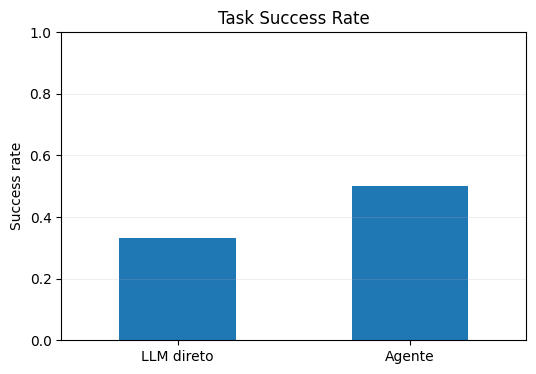

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

task_success_summary.plot(
    kind="bar"
)

plt.title(
    "Task Success Rate"
)
plt.ylabel("Success rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(
    axis="y",
    alpha=0.2,
)
plt.show()


## 21. Métricas de trajetória


In [24]:
trajectory_summary = pd.Series({
    "Tool Coverage":
        benchmark_results[
            "tool_coverage"
        ].mean(),

    "Exact Tool-Count Match":
        benchmark_results[
            "exact_tool_count_match"
        ].mean(),

    "Tool Execution Success":
        benchmark_results[
            "tool_execution_success"
        ].mean(),

    "Média de tool calls":
        benchmark_results[
            "tool_calls"
        ].mean(),

    "Média de passos":
        benchmark_results[
            "agent_steps"
        ].mean(),

    "Total de tool errors":
        benchmark_results[
            "tool_errors"
        ].sum(),
})

display(
    trajectory_summary
    .to_frame(
        "Resultado"
    )
    .round(4)
)


,Resultado
Tool Coverage,0.3333
Exact Tool-Count Match,0.3333
Tool Execution Success,1.0000
Média de tool calls,0.5000
Média de passos,1.5000
Total de tool errors,0.0000


## 22. Latência

O agente pode realizar várias inferências e chamadas de ferramentas antes de responder.

Por isso, maior task success normalmente vem com custo adicional de latência.


,Latência média (s)
LLM direto,3.324
Agente,6.288


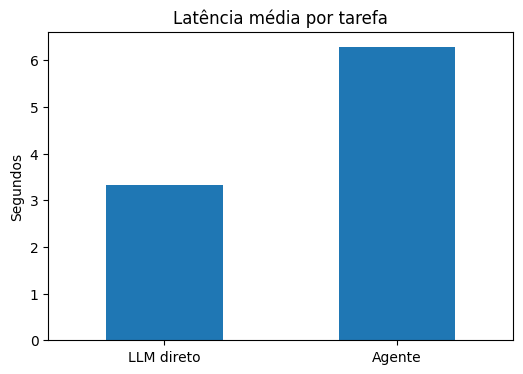

In [25]:
latency_summary = pd.Series({
    "LLM direto":
        benchmark_results[
            "direct_latency_s"
        ].mean(),

    "Agente":
        benchmark_results[
            "agent_latency_s"
        ].mean(),
})

display(
    latency_summary
    .to_frame(
        "Latência média (s)"
    )
    .round(3)
)

plt.figure(figsize=(6, 4))

latency_summary.plot(
    kind="bar"
)

plt.title(
    "Latência média por tarefa"
)
plt.ylabel("Segundos")
plt.xticks(rotation=0)
plt.show()


## 23. Ferramentas necessárias vs sucesso

A célula abaixo divide as tarefas pelo número mínimo de tool calls esperado.

Isso ajuda a observar degradação conforme a trajetória se torna mais longa.


In [26]:
required_call_counts = {
    task["id"]: sum(
        task[
            "required_tool_counts"
        ].values()
    )
    for task in BENCHMARK
}

benchmark_results[
    "required_tool_calls"
] = (
    benchmark_results[
        "id"
    ].map(
        required_call_counts
    )
)

complexity_summary = (
    benchmark_results
    .groupby(
        "required_tool_calls"
    )[
        [
            "direct_success",
            "agent_success",
            "tool_coverage",
            "exact_tool_count_match",
        ]
    ]
    .mean()
)

display(
    complexity_summary.round(4)
)


,direct_success,agent_success,tool_coverage,exact_tool_count_match
required_tool_calls,,,,
0,1.0,1.00,1.0,1.0
1,0.6,0.80,0.6,0.6
2,0.0,0.00,0.0,0.0
3,0.0,0.25,0.0,0.0


## 24. Análise das trajetórias que falharam

Erros podem ocorrer mesmo quando o modelo possui as ferramentas certas.

Exemplos:

- ferramenta errada;
- argumento incorreto;
- cálculo incorreto;
- parada precoce;
- loop;
- resposta final não incorporar o resultado da ferramenta.


In [27]:
failed_agent_tasks = (
    benchmark_results[
        benchmark_results[
            "agent_success"
        ] == 0
    ]
)

if failed_agent_tasks.empty:
    print(
        "Nenhuma tarefa do agente "
        "falhou nesta execução."
    )
else:
    display(
        failed_agent_tasks[
            [
                "id",
                "request",
                "agent_answer",
                "observed_tools",
                "tool_errors",
                "stop_reason",
            ]
        ]
    )


,id,request,agent_answer,observed_tools,tool_errors,stop_reason
0,T01,Which warehouse stores SKU A100?,I need to look up the warehouse that stores SK...,{},0,final_answer
2,T03,What is the total catalog price of 7 units of ...,"The Control Module, SKU C300, is priced at $39...",{'lookup_product': 1},0,final_answer
3,T04,What is the total shipment weight in grams for...,To find the total shipment weight in grams for...,{},0,final_answer
4,T05,What is the shipping cost for 5 units of SKU D...,To calculate the shipping cost for 5 units of ...,{},0,final_answer
8,T09,How many units of SKU A100 could be sold befor...,To find out how many units of SKU A100 could b...,{},0,final_answer
10,T11,"Which product is more expensive, SKU B200 or S...",To find out which product is more expensive an...,{},0,final_answer


## 25. Inspeção detalhada de uma trajetória

A célula seleciona:

1. a primeira tarefa que falhou; ou
2. a tarefa com maior número de passos, caso todas tenham sucesso.


In [28]:
if not failed_agent_tasks.empty:
    inspection_row = (
        failed_agent_tasks
        .iloc[0]
    )
else:
    inspection_row = (
        benchmark_results
        .sort_values(
            "agent_steps",
            ascending=False,
        )
        .iloc[0]
    )

print(
    "TASK:",
    inspection_row["id"],
)

print(
    "\nREQUEST:"
)
print(
    inspection_row[
        "request"
    ]
)

print(
    "\nFINAL ANSWER:"
)
print(
    inspection_row[
        "agent_answer"
    ]
)

print(
    "\nTRAJECTORY:"
)

display(
    pd.DataFrame(
        inspection_row[
            "trajectory"
        ]
    )
)


TASK: T01

REQUEST:
Which warehouse stores SKU A100?

FINAL ANSWER:
I need to look up the warehouse that stores SKU A100 in our private catalog. Please wait while I gather that information.

TRAJECTORY:


,step,type,content
0,1,final_answer,I need to look up the warehouse that stores SK...


## 26. Error recovery

Uma trajetória é considerada uma recuperação quando:

1. ocorre pelo menos um erro de ferramenta;
2. o agente ainda termina com resposta correta.

Isso mede resiliência, não apenas execução perfeita.


In [29]:
benchmark_results[
    "recovered_after_tool_error"
] = (
    (
        benchmark_results[
            "tool_errors"
        ] > 0
    )
    &
    (
        benchmark_results[
            "agent_success"
        ] == 1
    )
).astype(int)

tasks_with_tool_errors = (
    benchmark_results[
        benchmark_results[
            "tool_errors"
        ] > 0
    ]
)

if tasks_with_tool_errors.empty:
    print(
        "Nenhuma chamada de ferramenta "
        "falhou durante o benchmark."
    )
else:
    recovery_rate = (
        tasks_with_tool_errors[
            "recovered_after_tool_error"
        ].mean()
    )

    print(
        f"Recovery rate após tool error: "
        f"{recovery_rate:.3f}"
    )

    display(
        tasks_with_tool_errors[
            [
                "id",
                "tool_errors",
                "agent_success",
                "recovered_after_tool_error",
                "agent_answer",
            ]
        ]
    )


Nenhuma chamada de ferramenta falhou durante o benchmark.


## 27. Eficiência de trajetória

Task success não é suficiente.

Dois agentes podem responder corretamente, mas um pode utilizar várias chamadas redundantes.

Definimos:

```text
trajectory efficiency =
required tool calls / observed tool calls
```

para tarefas que exigem ferramentas.

O valor máximo é 1 quando não há chamadas extras.

Essa métrica é apenas uma aproximação simples: trajetórias diferentes podem ser igualmente válidas.


In [30]:
def trajectory_efficiency(row):
    required = row[
        "required_tool_calls"
    ]

    observed = row[
        "tool_calls"
    ]

    if required == 0:
        return (
            1.0
            if observed == 0
            else 0.0
        )

    if observed == 0:
        return 0.0

    return min(
        required / observed,
        1.0,
    )


benchmark_results[
    "trajectory_efficiency"
] = (
    benchmark_results.apply(
        trajectory_efficiency,
        axis=1,
    )
)

display(
    benchmark_results[
        [
            "id",
            "required_tool_calls",
            "tool_calls",
            "trajectory_efficiency",
            "agent_success",
        ]
    ]
)

print(
    "Eficiência média:",
    round(
        benchmark_results[
            "trajectory_efficiency"
        ].mean(),
        3,
    ),
)


,id,required_tool_calls,tool_calls,trajectory_efficiency,agent_success
0,T01,1,0,0.0,0
1,T02,1,0,0.0,1
2,T03,2,1,1.0,0
3,T04,3,0,0.0,0
4,T05,3,0,0.0,0
5,T06,1,1,1.0,1
6,T07,1,1,1.0,1
7,T08,0,0,1.0,1
8,T09,2,0,0.0,0
9,T10,3,2,1.0,1


Eficiência média: 0.5


## 28. Resumo end-to-end


In [31]:
end_to_end_summary = pd.Series({
    "Direct Task Success":
        benchmark_results[
            "direct_success"
        ].mean(),

    "Agent Task Success":
        benchmark_results[
            "agent_success"
        ].mean(),

    "Tool Coverage":
        benchmark_results[
            "tool_coverage"
        ].mean(),

    "Exact Tool-Count Match":
        benchmark_results[
            "exact_tool_count_match"
        ].mean(),

    "Trajectory Efficiency":
        benchmark_results[
            "trajectory_efficiency"
        ].mean(),

    "Tool Execution Success":
        benchmark_results[
            "tool_execution_success"
        ].mean(),

    "Agent Avg Steps":
        benchmark_results[
            "agent_steps"
        ].mean(),

    "Direct Avg Latency s":
        benchmark_results[
            "direct_latency_s"
        ].mean(),

    "Agent Avg Latency s":
        benchmark_results[
            "agent_latency_s"
        ].mean(),
})

display(
    end_to_end_summary
    .to_frame(
        "Resultado"
    )
    .round(4)
)


,Resultado
Direct Task Success,0.3333
Agent Task Success,0.5000
Tool Coverage,0.3333
Exact Tool-Count Match,0.3333
Trajectory Efficiency,0.5000
Tool Execution Success,1.0000
Agent Avg Steps,1.5000
Direct Avg Latency s,3.3238
Agent Avg Latency s,6.2876


## 29. Conclusão

A conclusão é construída com os resultados da execução atual.


In [32]:
from IPython.display import Markdown, display

direct_success = (
    benchmark_results[
        "direct_success"
    ].mean()
)

agent_success = (
    benchmark_results[
        "agent_success"
    ].mean()
)

tool_coverage = (
    benchmark_results[
        "tool_coverage"
    ].mean()
)

exact_trajectory = (
    benchmark_results[
        "exact_tool_count_match"
    ].mean()
)

trajectory_efficiency_mean = (
    benchmark_results[
        "trajectory_efficiency"
    ].mean()
)

tool_execution_success = (
    benchmark_results[
        "tool_execution_success"
    ].mean()
)

direct_latency = (
    benchmark_results[
        "direct_latency_s"
    ].mean()
)

agent_latency = (
    benchmark_results[
        "agent_latency_s"
    ].mean()
)

success_gain = (
    agent_success
    - direct_success
)

latency_multiplier = (
    agent_latency
    / direct_latency
    if direct_latency > 0
    else np.nan
)

total_errors = int(
    benchmark_results[
        "tool_errors"
    ].sum()
)

recovered_errors = int(
    benchmark_results[
        "recovered_after_tool_error"
    ].sum()
)

conclusion = f'''
### Síntese dos resultados

#### Resposta final

- **Task Success — LLM direto:** {direct_success:.3f}
- **Task Success — Agent:** {agent_success:.3f}
- **Diferença:** {success_gain:+.3f}

#### Trajetória

- **Tool Coverage:** {tool_coverage:.3f}
- **Exact Tool-Count Match:** {exact_trajectory:.3f}
- **Trajectory Efficiency:** {trajectory_efficiency_mean:.3f}
- **Tool Execution Success:** {tool_execution_success:.3f}

#### Falhas e recuperação

- **Tool errors observados:** {total_errors}
- **Tarefas recuperadas após tool error:** {recovered_errors}

#### Latência

- **LLM direto:** {direct_latency:.2f} s/tarefa
- **Agent:** {agent_latency:.2f} s/tarefa
- **Multiplicador de latência:** {latency_multiplier:.2f}x

### Interpretação

Ferramentas mudam a natureza do sistema.

O LLM deixa de depender apenas dos próprios pesos e passa a interagir com um ambiente externo.

Isso é particularmente importante quando a tarefa depende de:

- dados privados;
- valores atualizados;
- cálculos exatos;
- operações externas;
- múltiplas etapas.

### Resposta correta não significa trajetória correta

Um agente pode chegar ao resultado certo:

- usando uma ferramenta errada;
- executando chamadas redundantes;
- fazendo parte do cálculo mentalmente;
- ignorando um erro intermediário por sorte.

Por isso, Agent Evaluation precisa observar pelo menos duas dimensões:

**Outcome**
> A tarefa foi concluída?

**Trajectory**
> O agente percorreu um caminho válido e eficiente?

### Segurança arquitetural

O notebook também demonstra que tool calling deve possuir uma camada de execução separada.

O modelo:

> propõe ações.

O executor:

> valida e executa ações.

Essa fronteira é essencial para ferramentas que tenham efeitos reais.

### Trade-off

O agente tende a trocar:

**mais capacidade**

por:

**mais passos + mais inferências + maior latência + maior superfície de erro**

Assim, nem toda tarefa precisa de um agente.

Para perguntas que não exigem ferramentas, a execução direta pode ser mais simples e eficiente.

### Limitações

- ambiente de ferramentas é pequeno e controlado;
- benchmark contém apenas 12 tarefas;
- não há chamadas HTTP ou sistemas externos reais;
- não existem ferramentas com efeitos irreversíveis;
- não há autenticação ou autorização;
- apenas um modelo foi avaliado;
- trajetórias mínimas foram definidas manualmente;
- a métrica de eficiência é simplificada;
- não há avaliação de custo monetário;
- tarefas não incluem contexto conversacional longo.

### Próximos experimentos

1. aumentar o benchmark;
2. testar diferentes modelos;
3. adicionar ferramentas HTTP reais;
4. introduzir timeout e retry;
5. criar ferramentas com permissões;
6. adicionar confirmação humana para ações sensíveis;
7. avaliar tool-selection precision/recall;
8. medir custo por tarefa;
9. introduzir memória persistente;
10. testar planejamento explícito.

### Próximo estudo — Study 012: Multi-Agent

O próximo passo será observar se uma tarefa complexa deve ser resolvida por:

**um único agente com todas as ferramentas**

ou por:

**agentes especializados coordenados por um supervisor.**

Isso permitirá estudar:

- delegation;
- routing;
- specialization;
- shared state;
- handoffs;
- coordination overhead;
- error propagation;
- comparação single-agent vs multi-agent.
'''

display(
    Markdown(conclusion)
)



### Síntese dos resultados

#### Resposta final

- **Task Success — LLM direto:** 0.333
- **Task Success — Agent:** 0.500
- **Diferença:** +0.167

#### Trajetória

- **Tool Coverage:** 0.333
- **Exact Tool-Count Match:** 0.333
- **Trajectory Efficiency:** 0.500
- **Tool Execution Success:** 1.000

#### Falhas e recuperação

- **Tool errors observados:** 0
- **Tarefas recuperadas após tool error:** 0

#### Latência

- **LLM direto:** 3.32 s/tarefa
- **Agent:** 6.29 s/tarefa
- **Multiplicador de latência:** 1.89x

### Interpretação

Ferramentas mudam a natureza do sistema.

O LLM deixa de depender apenas dos próprios pesos e passa a interagir com um ambiente externo.

Isso é particularmente importante quando a tarefa depende de:

- dados privados;
- valores atualizados;
- cálculos exatos;
- operações externas;
- múltiplas etapas.

### Resposta correta não significa trajetória correta

Um agente pode chegar ao resultado certo:

- usando uma ferramenta errada;
- executando chamadas redundantes;
- fazendo parte do cálculo mentalmente;
- ignorando um erro intermediário por sorte.

Por isso, Agent Evaluation precisa observar pelo menos duas dimensões:

**Outcome**
> A tarefa foi concluída?

**Trajectory**
> O agente percorreu um caminho válido e eficiente?

### Segurança arquitetural

O notebook também demonstra que tool calling deve possuir uma camada de execução separada.

O modelo:

> propõe ações.

O executor:

> valida e executa ações.

Essa fronteira é essencial para ferramentas que tenham efeitos reais.

### Trade-off

O agente tende a trocar:

**mais capacidade**

por:

**mais passos + mais inferências + maior latência + maior superfície de erro**

Assim, nem toda tarefa precisa de um agente.

Para perguntas que não exigem ferramentas, a execução direta pode ser mais simples e eficiente.

### Limitações

- ambiente de ferramentas é pequeno e controlado;
- benchmark contém apenas 12 tarefas;
- não há chamadas HTTP ou sistemas externos reais;
- não existem ferramentas com efeitos irreversíveis;
- não há autenticação ou autorização;
- apenas um modelo foi avaliado;
- trajetórias mínimas foram definidas manualmente;
- a métrica de eficiência é simplificada;
- não há avaliação de custo monetário;
- tarefas não incluem contexto conversacional longo.

### Próximos experimentos

1. aumentar o benchmark;
2. testar diferentes modelos;
3. adicionar ferramentas HTTP reais;
4. introduzir timeout e retry;
5. criar ferramentas com permissões;
6. adicionar confirmação humana para ações sensíveis;
7. avaliar tool-selection precision/recall;
8. medir custo por tarefa;
9. introduzir memória persistente;
10. testar planejamento explícito.

### Próximo estudo — Study 012: Multi-Agent

O próximo passo será observar se uma tarefa complexa deve ser resolvida por:

**um único agente com todas as ferramentas**

ou por:

**agentes especializados coordenados por um supervisor.**

Isso permitirá estudar:

- delegation;
- routing;
- specialization;
- shared state;
- handoffs;
- coordination overhead;
- error propagation;
- comparação single-agent vs multi-agent.


## 30. Principais aprendizados

### 1. Tool calling não é execução

O LLM produz uma solicitação estruturada.  
A aplicação continua responsável por validar e executar.

### 2. Estado é parte do agente

Sem histórico de tool calls e tool responses, o modelo não consegue continuar uma tarefa multi-step de forma consistente.

### 3. Ferramentas devem ter contratos claros

Nome, argumentos, tipos e descrições influenciam diretamente a capacidade do modelo de selecionar e utilizar ferramentas.

### 4. Erros precisam voltar ao agente

Esconder uma falha da ferramenta impede recuperação.

### 5. Stop conditions são obrigatórias

Sem limite de passos, agentes podem entrar em loops.

### 6. Outcome e trajectory são métricas diferentes

Uma resposta correta não prova que a execução foi segura ou eficiente.

### 7. Nem tudo precisa ser agentic

Se uma única chamada determinística resolve a tarefa, adicionar um loop autônomo pode aumentar custo e risco sem benefício.


## Referências

- Hugging Face Transformers — Tool Use;
- Hugging Face Transformers — Chat Templates;
- Hugging Face Transformers — JSON schemas para ferramentas;
- NousResearch — Hermes 2 Pro Llama 3;
- Python `ast` — parsing utilizado pela calculadora segura.

### Observação de implementação

A API moderna do Transformers representa uma solicitação de ferramenta no histórico como uma mensagem `assistant` contendo `tool_calls`, seguida de uma mensagem com role `tool` contendo o resultado.

O conteúdo devolvido pela ferramenta é serializado como string antes de ser reinserido na conversa.

### Reprodutibilidade

Para publicação:

1. execute todo o notebook em um único runtime;
2. preserve os outputs;
3. registre versão de Transformers;
4. registre GPU utilizada;
5. mantenha temperatura/amostragem determinísticas;
6. não altere o benchmark após observar o resultado.
